# Dokumentasi Kode: Perbandingan Strategi Portofolio Berbasis Graph dan GNN
Notebook ini direkonstruksi dari dokumentasi LaTeX untuk tesis, membandingkan berbagai strategi alokasi portofolio pada aset kripto.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
from scipy import stats
import torch
import torch.nn as nn
torch.set_default_dtype(torch.float32)
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Libraries imported successfully!')
print(f'PyTorch: {torch.__version__}')

Libraries imported successfully!
PyTorch: 2.9.1+cpu


## 2. Load & Prepare Real Crypto Data

In [2]:
EXCEL_FILE = 'crypto_data_real.xlsx'
df_raw = pd.read_excel(EXCEL_FILE, sheet_name='Returns', index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.sort_index(inplace=True)
df_raw = df_raw.drop(columns=['USDT'], errors='ignore')  # stablecoin

# Hanya simpan baris di mana semua aset sudah aktif (return != 0)
mask = (df_raw != 0).all(axis=1)
df_returns = df_raw[mask].copy()

# Sub-period labels
BULL_END  = '2017-12-31'   # Bull: Nov 2017 - Des 2017
BEAR_END  = '2018-12-31'   # Bear: Jan 2018 - Des 2018
# Recovery: Jan 2019 - Okt 2019

periods = {
    'Bull (Nov-Dec 2017)' : df_returns.loc[df_returns.index <= BULL_END],
    'Bear (2018)'         : df_returns.loc[
                                (df_returns.index > BULL_END) &
                                (df_returns.index <= BEAR_END)],
    'Recovery (2019)'     : df_returns.loc[df_returns.index > BEAR_END],
    'Full Period'         : df_returns,
}

print('=== DATASET SUMMARY ===')
print(f'Assets  : {df_returns.columns.tolist()}')
print(f'Period  : {df_returns.index.min().date()} -> {df_returns.index.max().date()}')
print(f'Obs     : {len(df_returns)} trading days')
for pname, pdf in periods.items():
    print(f'{pname:<22}: {len(pdf):>4} days')
print(df_returns.describe().round(4))

=== DATASET SUMMARY ===
Assets  : ['BTC', 'ETH', 'XRP', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
Period  : 2017-11-10 -> 2019-10-17
Obs     : 706 trading days
Bull (Nov-Dec 2017)   :   52 days
Bear (2018)           :  364 days
Recovery (2019)       :  290 days
Full Period           :  706 days
            BTC       ETH       XRP       BCH       LTC       BNB       EOS  \
count  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000   
mean     0.0002   -0.0008    0.0005   -0.0016   -0.0002    0.0032    0.0013   
std      0.0434    0.0527    0.0680    0.0752    0.0591    0.0645    0.0737   
min     -0.1846   -0.2069   -0.3520   -0.4096   -0.2119   -0.3424   -0.3015   
25%     -0.0173   -0.0237   -0.0267   -0.0336   -0.0287   -0.0258   -0.0306   
50%      0.0016   -0.0003   -0.0025   -0.0038   -0.0028    0.0000   -0.0005   
75%      0.0186    0.0248    0.0203    0.0256    0.0275    0.0310    0.0297   
max      0.2251    0.2347    0.6069    0.4316    0.3893    0.4818    0.3

## 3. Helper Functions

In [3]:
def apply_rmt_filter(returns_data):
    T, N = returns_data.shape
    Q = T / N
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    # Balik urutan (terbesar ke terkecil)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    # Batas Marchenko-Pastur
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    # Nolkan nilai eigen yang dianggap noise
    Lambda_f = np.diag(np.where(eigenvalues > lambda_plus, eigenvalues, 0))
    return eigenvectors @ Lambda_f @ eigenvectors.T

def build_mst(correlation_matrix):
    # Pastikan korelasi berada dalam rentang [-1, 1] untuk menghindari NaN dalam sqrt
    correlation_matrix = np.clip(correlation_matrix, -1, 1)
    d = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(d, 0)
    return d

def compute_eigenvector_centrality(distance_matrix):
    adj = 1 / (distance_matrix + 1e-8)   # adjacency = 1/jarak
    np.fill_diagonal(adj, 0)
    _, vecs = eigh(adj)
    pev = np.abs(vecs[:, -1])             # eigenvector terbesar
    return pev / pev.sum()                # normalisasi

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    # Urutkan aset berdasarkan rata-rata return (terbesar duluan)
    # Sesuai logika di dokumen: aset dengan return tinggi diprioritaskan
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    # Menggunakan MIS aproksimasi (sesuai literatur Giudici)
    return list(nx.approximation.maximum_independent_set(G))

# Metrik Risiko
def calculate_var(returns, confidence=0.95):
    """Value at Risk pada level kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Rasio rata-rata tail atas terhadap tail bawah."""
    tu = np.percentile(returns, (1 - alpha) * 100)   # upper tail
    tl = np.percentile(returns, alpha * 100)           # lower tail
    cu = returns[returns >= tu].mean()
    cl = abs(returns[returns <= tl].mean())
    return cu / cl if cl > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Drawdown maksimum dari nilai kumulatif portofolio."""
    running_max = np.maximum.accumulate(cumulative_returns)
    # Hindari pembagian dengan nol
    drawdown = (cumulative_returns - running_max) / (running_max + 1e-12)
    return drawdown.min()

def calculate_calmar_ratio(returns, cum_returns):
    """Calmar Ratio = Return Tahunan / |Max Drawdown|."""
    ann_ret = np.mean(returns) * 252
    mdd     = abs(calculate_max_drawdown(cum_returns))
    return ann_ret / mdd if mdd > 0 else 0

def diebold_mariano_test(returns_a, returns_b, h=1):
    T   = len(returns_a)
    d   = returns_a - returns_b      # selisih return harian
    d_mean = np.mean(d)

    def autocov(xi, xm, k):
        T_ = len(xi)
        return np.sum((xi[:T_-k] - xm) * (xi[k:] - xm)) / T_ if T_ > k else 0

    var_d = autocov(d, d_mean, 0)
    for i in range(1, h):
        var_d += 2 * autocov(d, d_mean, i)

    dm = d_mean / np.sqrt(abs(var_d) / T) if var_d != 0 else 0
    pv = 2 * (1 - stats.norm.cdf(abs(dm)))
    return dm, pv

## 4. Graph Neural Network (GCN Architecture)

In [4]:
class CorrelationGNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_correlation(self, emb):
        """Prediksi korelasi via cosine similarity embedding."""
        n = emb.shape[0]
        C = torch.zeros(n, n)
        for i in range(n):
            for j in range(i+1, n):
                s = F.cosine_similarity(emb[i].unsqueeze(0),
                                        emb[j].unsqueeze(0))
                C[i, j] = C[j, i] = s
        # Diagonal tetap 1
        for i in range(n): C[i,i] = 1.0
        return C

def create_graph_data(returns_window, corr_threshold=0.3):
    n = returns_window.shape[1]
    feats = np.stack([
        returns_window.mean().values,
        returns_window.std().values,
        returns_window.skew().values,
        returns_window.kurtosis().values
    ], axis=1)
    x    = torch.FloatTensor(feats)
    corr = returns_window.corr().values

    # Buat edge list dari pasangan yang berkorelasi
    edges = [[i, j] for i in range(n) for j in range(i+1, n)
             if abs(corr[i, j]) > corr_threshold]
    # Mirror untuk undirected
    all_edges = []
    for i, j in edges:
        all_edges.append([i, j])
        all_edges.append([j, i])
    
    if not all_edges:                           # fallback: graf penuh
        all_edges = [[i, j] for i in range(n) for j in range(n) if i != j]

    ei = torch.LongTensor(all_edges).t().contiguous()
    return Data(x=x, edge_index=ei, y=torch.FloatTensor(corr))

def train_gnn(model, data, epochs=50, lr=0.01):
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        emb  = model(data.x, data.edge_index)
        pred = model.predict_correlation(emb)
        loss = loss_fn(pred, data.y)
        loss.backward()
        opt.step()
    return model

## 5. Portfolio Strategy Classes

In [5]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
    def get_weights(self, r):
        raise NotImplementedError

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, r):
        n = r.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, r):
        n  = r.shape[1]
        mu = r.mean().values
        S  = r.cov().values
        f  = lambda w: w @ S @ w
        c  = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
              {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res = minimize(f, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class GlassoMarkowitz(PortfolioStrategy):
    def __init__(self, name='Glasso Markowitz', alpha=0.01):
        super().__init__(name)
        self.alpha = alpha

    def get_weights(self, r):
        n  = r.shape[1]
        mu = r.mean().values
        try:
            g = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            g.fit(r.values)
            S = g.covariance_
        except:
            S = r.cov().values   # fallback ke kovarians biasa
        f  = lambda w: w @ S @ w
        c  = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
              {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res = minimize(f, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, r):
        n    = r.shape[1]
        mu   = r.mean().values
        sig  = r.std().values
        Cf   = apply_rmt_filter(r)
        dm   = build_mst(Cf)
        cent = compute_eigenvector_centrality(dm)
        Sf   = np.outer(sig, sig) * Cf   # Kovarians dari korelasi RMT
        f    = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        c    = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
                {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res  = minimize(f, np.ones(n)/n, method='SLSQP',
                        bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class GraphDiversification(PortfolioStrategy):
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w

class GNNGraphDiversification(PortfolioStrategy):
    def __init__(self, name='GNN GD', base_threshold=0.4, train_epochs=30):
        super().__init__(name)
        self.base_threshold = base_threshold
        self.train_epochs   = train_epochs
        self.gnn_model      = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=8)

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()

        # 1) Buat graph data & latih GNN
        gd = create_graph_data(r, corr_threshold=0.3)
        self.gnn_model = train_gnn(self.gnn_model, gd,
                                   epochs=self.train_epochs)
        # 2) Prediksi korelasi dari embedding GCN
        self.gnn_model.eval()
        with torch.no_grad():
            emb = self.gnn_model(gd.x, gd.edge_index)
            pc  = self.gnn_model.predict_correlation(emb)

        pn = pc.numpy()
        up = pn[np.triu_indices(n, k=1)]

        # 3) Threshold adaptif
        thr = np.clip(np.mean(np.abs(up)) + 0.5*np.std(np.abs(up)), 0.3, 0.7)

        # 4) Bangun graf dengan threshold adaptif
        G       = nx.Graph()
        asorted = list(r.mean().sort_values(ascending=False).index)
        G.add_nodes_from(asorted)
        for i, a1 in enumerate(asorted):
            for a2 in asorted[i+1:]:
                i1, i2 = assets.index(a1), assets.index(a2)
                if abs(pn[i1, i2]) > thr:
                    G.add_edge(a1, a2)

        # 5) MIS & equal weighting
        sel = list(nx.approximation.maximum_independent_set(G))
        w   = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w

## 6. Backtesting Framework

In [6]:
def backtest_strategy(strategy, df_ret, window_size=120,
                      rebalance_freq=7, transaction_cost=0.001):
    port_returns = []
    dates        = []
    for i in range(window_size, len(df_ret), rebalance_freq):
        train = df_ret.iloc[i-window_size:i]
        w     = strategy.get_weights(train)
        test_end = min(i + rebalance_freq, len(df_ret))
        test     = df_ret.iloc[i:test_end]
        for j in range(len(test)):
            dr = np.dot(w, test.iloc[j].values)
            if j == 0 and port_returns:
                dr -= transaction_cost   # biaya transaksi saat rebalancing
            port_returns.append(dr)
            dates.append(test.index[j])

    res = pd.DataFrame({'date': dates, 'return': port_returns})
    res['cumulative_return'] = (1 + res['return']).cumprod()
    return {
        'strategy'          : strategy.name,
        'returns'           : np.array(port_returns),
        'cumulative_returns': res['cumulative_return'].values,
        'dates'             : dates,
        'results_df'        : res
    }

def calculate_metrics(result):
    r  = result['returns']
    cr = result['cumulative_returns']
    ann_r = np.mean(r) * 252              # Return tahunan
    ann_v = np.std(r) * np.sqrt(252)      # Volatilitas tahunan
    sharpe = ann_r / ann_v if ann_v > 0 else 0
    return {
        'Strategy'          : result['strategy'],
        'Total Return (%)'  : round((cr[-1] - 1) * 100, 2),
        'Annual Return (%)' : round(ann_r * 100, 2),
        'Annual Vol (%)'    : round(ann_v * 100, 2),
        'Sharpe Ratio'      : round(sharpe, 4),
        'VaR 95% (%)'       : round(calculate_var(r, 0.95) * 100, 4),
        'Rachev Ratio'      : round(calculate_rachev_ratio(r, 0.10), 4),
        'Max Drawdown (%)'  : round(calculate_max_drawdown(cr) * 100, 2),
        'Calmar Ratio'      : round(calculate_calmar_ratio(r, cr), 4),
    }

## 7. Menjalankan Backtest (Full Period)

In [7]:
strategies = [
    EquallyWeighted('Equally Weighted'),
    ClassicalMarkowitz('Classical Markowitz'),
    GlassoMarkowitz('Glasso Markowitz', alpha=0.01),
    NetworkMarkowitz('Network Markowitz (gamma=0)',   gamma=0),
    NetworkMarkowitz('Network Markowitz (gamma=1.0)', gamma=1.0),
    GraphDiversification('Graph Divers. (theta=0.4)', corr_threshold=0.4),
    GraphDiversification('Graph Divers. (theta=0.5)', corr_threshold=0.5),
    GNNGraphDiversification('GNN Graph Divers. (30 ep)', train_epochs=30),
    GNNGraphDiversification('GNN Graph Divers. (50 ep)', train_epochs=50),
]

print('Running backtests on real crypto data...')
results = {}
for s in strategies:
    print(f'  Testing: {s.name}...')
    results[s.name] = backtest_strategy(
        s, df_returns, window_size=120, rebalance_freq=7)
    print(f'  Done')
print('\nAll backtests completed.')

Running backtests on real crypto data...
  Testing: Equally Weighted...
  Done
  Testing: Classical Markowitz...
  Done
  Testing: Glasso Markowitz...
  Done
  Testing: Network Markowitz (gamma=0)...
  Done
  Testing: Network Markowitz (gamma=1.0)...
  Done
  Testing: Graph Divers. (theta=0.4)...
  Done
  Testing: Graph Divers. (theta=0.5)...
  Done
  Testing: GNN Graph Divers. (30 ep)...
  Done
  Testing: GNN Graph Divers. (50 ep)...
  Done

All backtests completed.


## 8. Performance Metrics

In [8]:
metrics_df = pd.DataFrame(
    [calculate_metrics(r) for r in results.values()]
).set_index('Strategy')

def highlight_best(col):
    """Highlight nilai terbaik per kolom."""
    is_min = col.name in ['Annual Vol (%)', 'VaR 95% (%)', 'Max Drawdown (%)']
    best   = col.min() if is_min else col.max()
    return ['background-color: #d4edda; font-weight: bold'
            if v == best else '' for v in col]

print('PERFORMANCE METRICS (full period)')
print('='*100)
print(metrics_df.to_string())
print('='*100)
metrics_df.style.apply(highlight_best)

PERFORMANCE METRICS (full period)
                               Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)  Calmar Ratio
Strategy                                                                                                                                                   
Equally Weighted                         -78.43             -40.43           70.72       -0.5717      -7.6072        0.8401            -87.80       -0.4604
Classical Markowitz                      -70.71             -35.31           58.53       -0.6033      -6.3367        0.8272            -76.57       -0.4611
Glasso Markowitz                         -70.71             -35.31           58.53       -0.6033      -6.3367        0.8272            -76.57       -0.4611
Network Markowitz (gamma=0)              -69.62             -33.87           58.37       -0.5803      -6.5036        0.8434            -77.77       -0.4355
Network Markowitz (gamma=1.0) 

,Total Return (%),Annual Return (%),Annual Vol (%),Sharpe Ratio,VaR 95% (%),Rachev Ratio,Max Drawdown (%),Calmar Ratio
Strategy,,,,,,,,
Equally Weighted,-78.430000,-40.430000,70.720000,-0.571700,-7.607200,0.840100,-87.800000,-0.460400
Classical Markowitz,-70.710000,-35.310000,58.530000,-0.603300,-6.336700,0.827200,-76.570000,-0.461100
Glasso Markowitz,-70.710000,-35.310000,58.530000,-0.603300,-6.336700,0.827200,-76.570000,-0.461100
Network Markowitz (gamma=0),-69.620000,-33.870000,58.370000,-0.580300,-6.503600,0.843400,-77.770000,-0.435500
Network Markowitz (gamma=1.0),-71.670000,-27.190000,73.290000,-0.371000,-7.945200,0.983300,-87.620000,-0.310300
Graph Divers. (theta=0.4),-86.620000,-49.370000,86.640000,-0.569800,-8.490000,0.998300,-92.780000,-0.532100
Graph Divers. (theta=0.5),-74.800000,-22.110000,86.820000,-0.254700,-8.705600,0.978200,-92.860000,-0.238100
GNN Graph Divers. (30 ep),-91.170000,-68.000000,85.660000,-0.793800,-8.764200,0.972500,-93.320000,-0.728700
GNN Graph Divers. (50 ep),-77.510000,-38.760000,70.560000,-0.549300,-7.607200,0.846300,-87.800000,-0.441400


## 9. Validasi Statistik (Matriks DM)

In [9]:
strategy_names = list(results.keys())
n_strat = len(strategy_names)

dm_stat_mat = pd.DataFrame(index=strategy_names,
                            columns=strategy_names, dtype=float)
dm_pval_mat = pd.DataFrame(index=strategy_names,
                            columns=strategy_names, dtype=float)

for i, s1 in enumerate(strategy_names):
    for j, s2 in enumerate(strategy_names):
        if i == j:
            dm_stat_mat.loc[s1, s2] = 0.0
            dm_pval_mat.loc[s1, s2] = 1.0
        else:
            dm, pv = diebold_mariano_test(
                results[s1]['returns'], results[s2]['returns'])
            dm_stat_mat.loc[s1, s2] = round(dm, 3)
            dm_pval_mat.loc[s1, s2] = round(pv, 4)

sig_matrix = dm_pval_mat < 0.05   # True = signifikan
print('DM Test P-Value Matrix (p < 0.05 = significant)')
print(dm_pval_mat.to_string())
print()
print('DM Test Statistic Matrix (positive = row outperforms column)')
print(dm_stat_mat.to_string())

DM Test P-Value Matrix (p < 0.05 = significant)
                               Equally Weighted  Classical Markowitz  Glasso Markowitz  Network Markowitz (gamma=0)  Network Markowitz (gamma=1.0)  Graph Divers. (theta=0.4)  Graph Divers. (theta=0.5)  GNN Graph Divers. (30 ep)  GNN Graph Divers. (50 ep)
Equally Weighted                         1.0000               0.7441            0.7441                       0.7200                         0.6606                     0.7529                     0.5196                     0.3070                     0.2474
Classical Markowitz                      0.7441               1.0000            1.0000                       0.8375                         0.7741                     0.6723                     0.6904                     0.3050                     0.8269
Glasso Markowitz                         0.7441               1.0000            1.0000                       0.8375                         0.7741                     0.6723              

## 10. Heatmap DM Test

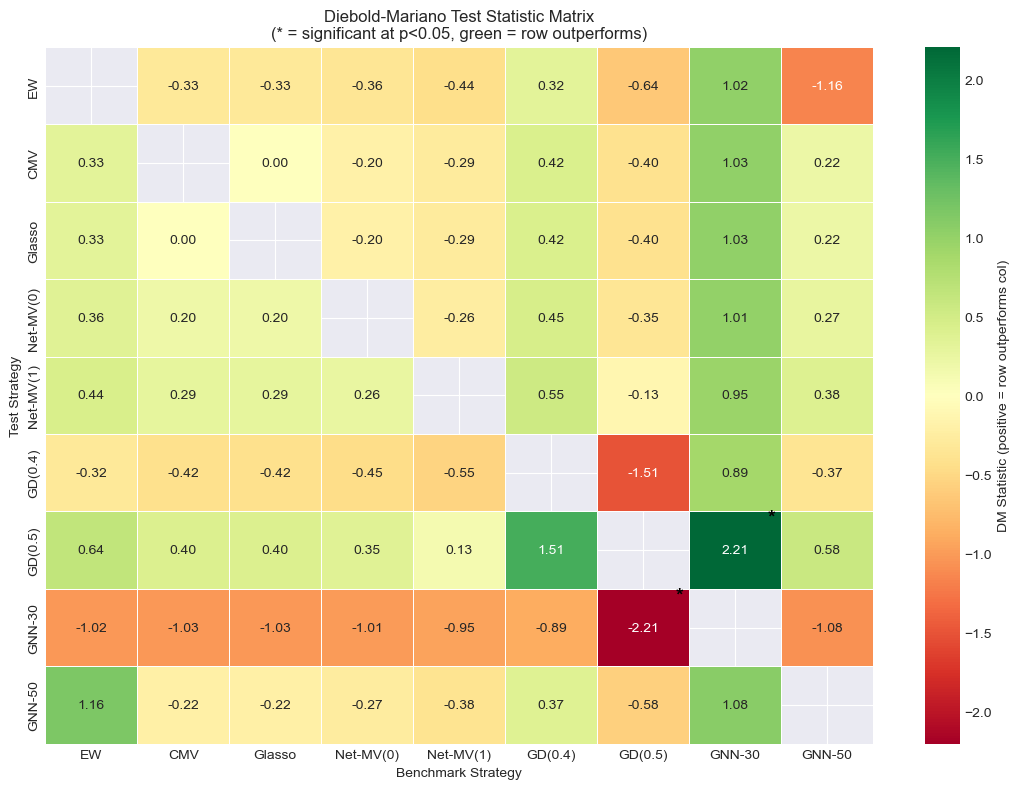

Saved: dm_test_heatmap.png


In [10]:
# Singkat nama strategi agar muat di heatmap
short_names = {
    'Equally Weighted'              : 'EW',
    'Classical Markowitz'           : 'CMV',
    'Glasso Markowitz'              : 'Glasso',
    'Network Markowitz (gamma=0)'   : 'Net-MV(0)',
    'Network Markowitz (gamma=1.0)' : 'Net-MV(1)',
    'Graph Divers. (theta=0.4)'     : 'GD(0.4)',
    'Graph Divers. (theta=0.5)'     : 'GD(0.5)',
    'GNN Graph Divers. (30 ep)'     : 'GNN-30',
    'GNN Graph Divers. (50 ep)'     : 'GNN-50',
}
dm_stat_r = dm_stat_mat.rename(index=short_names, columns=short_names).astype(float)
pval_r    = dm_pval_mat.rename(index=short_names, columns=short_names).astype(float)

fig, ax = plt.subplots(figsize=(11, 8))
mask_diag = np.eye(len(dm_stat_r), dtype=bool)
sns.heatmap(dm_stat_r, annot=True, fmt='.2f', center=0, cmap='RdYlGn',
            linewidths=0.5, ax=ax, mask=mask_diag,
            cbar_kws={'label': 'DM Statistic (positive = row outperforms col)'})

# Tambah tanda '*' untuk sel yang signifikan
for i in range(len(dm_stat_r)):
    for j in range(len(dm_stat_r.columns)):
        if i != j and pval_r.iloc[i, j] < 0.05:
            ax.text(j+0.85, i+0.15, '*', color='black',
                    fontsize=14, fontweight='bold')

ax.set_title('Diebold-Mariano Test Statistic Matrix\n'
             '(* = significant at p<0.05, green = row outperforms)',
             fontsize=12)
ax.set_xlabel('Benchmark Strategy')
ax.set_ylabel('Test Strategy')
plt.tight_layout()
plt.savefig('dm_test_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dm_test_heatmap.png')

## 11. Visualisasi Cumulative Returns

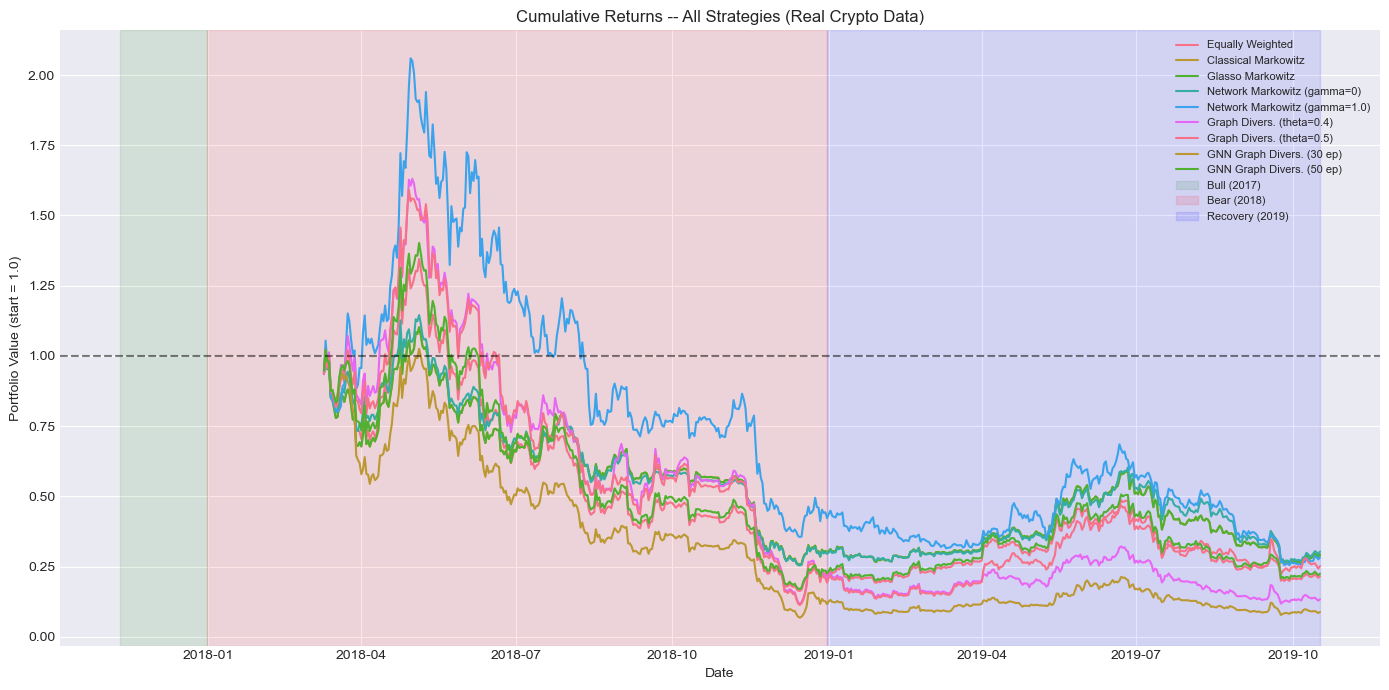

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot setiap strategi
for name, res in results.items():
    ax.plot(res['dates'], res['cumulative_returns'], label=name)

# Tambah shading fase pasar
ax.axvspan(df_returns.index.min(), pd.Timestamp(BULL_END),
           alpha=0.1, color='green', label='Bull (2017)')
ax.axvspan(pd.Timestamp(BULL_END), pd.Timestamp(BEAR_END),
           alpha=0.1, color='red', label='Bear (2018)')
ax.axvspan(pd.Timestamp(BEAR_END), df_returns.index.max(),
           alpha=0.1, color='blue', label='Recovery (2019)')

ax.axhline(y=1, color='black', linestyle='--', alpha=0.5)
ax.set_title('Cumulative Returns -- All Strategies (Real Crypto Data)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('cumulative_returns_comparison_reconstructed.png', dpi=150, bbox_inches='tight')
plt.show()